# EDA and Featurization

## This notebook cleans the data, computes correlations, cuts redundant features, and analyses the target property distribution

### *imports*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### *load, inspect, drop NaNs*

In [2]:
# Define the file path for the data set
file_path = "data/GEOM_mosaec-db.csv"

# Load the CSV file into a pandas DataFrame
df_geom = pd.read_csv(file_path)

# Check shape again
if df_geom.shape != (124469, 24):
    print("\nERROR: Unexpected df shape... warning, code may break... continuining script anyways...\n")
else:
    print("\nData loaded...\n")

# Print all column names
print(f"Total Columns Found: {len(df_geom.columns)}")
print("Column Names:")
for col in df_geom.columns:
    print(col)

# Print total of all NaN containing rows
print("\nTotal of NaNs:", df_geom.isna().any(axis=1).sum())

# Drop NaN containing rows
df_clean = df_geom.dropna(inplace=False)

# Print number of all NaN containing rows after cleaning
print("\nTotal of NaNs after cleaning:", df_clean.isna().any(axis=1).sum())

# Display cleaned shape
print("\nCleaned DataFrame Shape:", df_clean.shape)

# Create features DataFrame by dropping the grouping column and the target column
df_features = df_clean.drop(columns=['cif', 'Largest free sphere'])

# Display features shape
print("\nFeatures DataFrame Shape:", df_features.shape, "\n")


Data loaded...

Total Columns Found: 24
Column Names:
cif
Unitcell_volume
Density
ASA_A^2
ASA_m^2/cm^3
ASA_m^2/g
NASA_A^2
NASA_m^2/cm^3
NASA_m^2/g
Largest included sphere
Largest free sphere
Largest included sphere along free sphere path
AV_A^3
AV_Volume_fraction
AV_cm^3/g
NAV_A^3
NAV_Volume_fraction
NAV_cm^3/g
POAV_A^3
POAV_Volume_fraction
POAV_cm^3/g
PONAV_A^3
PONAV_Volume_fraction
PONAV_cm^3/g

Total of NaNs: 2

Total of NaNs after cleaning: 0

Cleaned DataFrame Shape: (124467, 24)

Features DataFrame Shape: (124467, 22) 



### *calculate and display initial correlations*

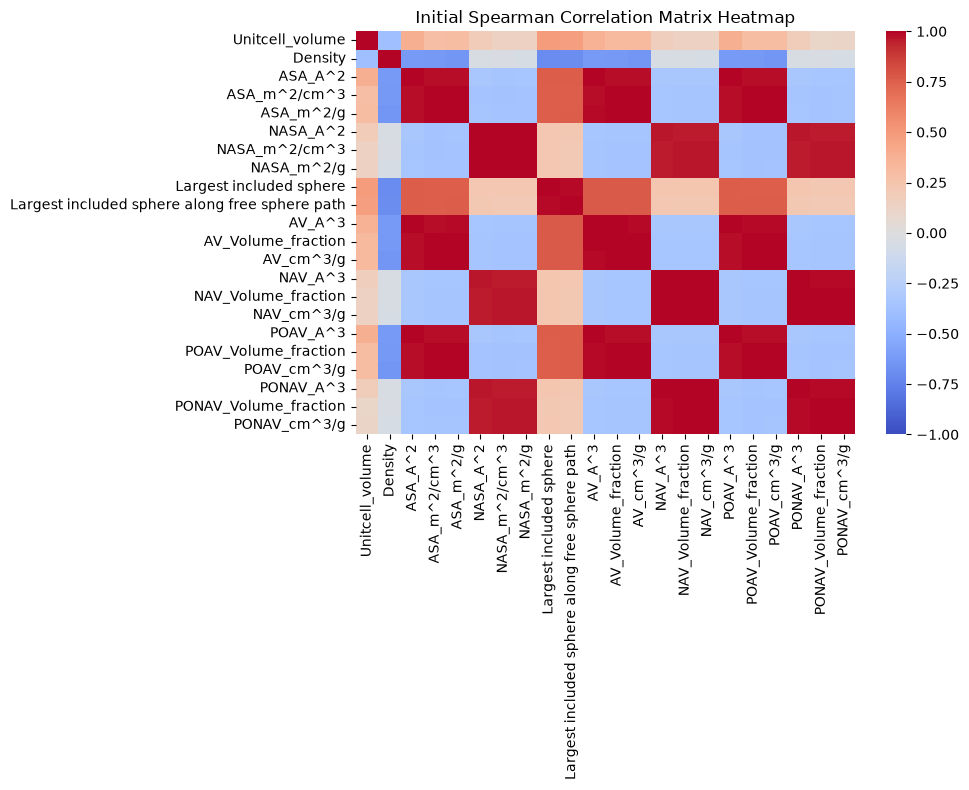

In [3]:
# Compute the correlation matrix by Spearman rank 
corr_matrix = df_features.corr(method="spearman").abs() # filtering by absolute value of correlation

# Visualize raw correlation (show negative correlations, NOT absolute value)
visual_corr_matrix = df_features.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(visual_corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Initial Spearman Correlation Matrix Heatmap")

# Save figure
plt.tight_layout()
plt.savefig('figures/initial_corr_heatmap.png')

### *cut most correlated features and show new heatmap*


Dropped 2 features related to pore geometry

Dropped 12 repeat features (different units only)

Columns remaining: 8

Dropped 3 correlated features

Reduced Features DataFrame Shape:  (124467, 5)


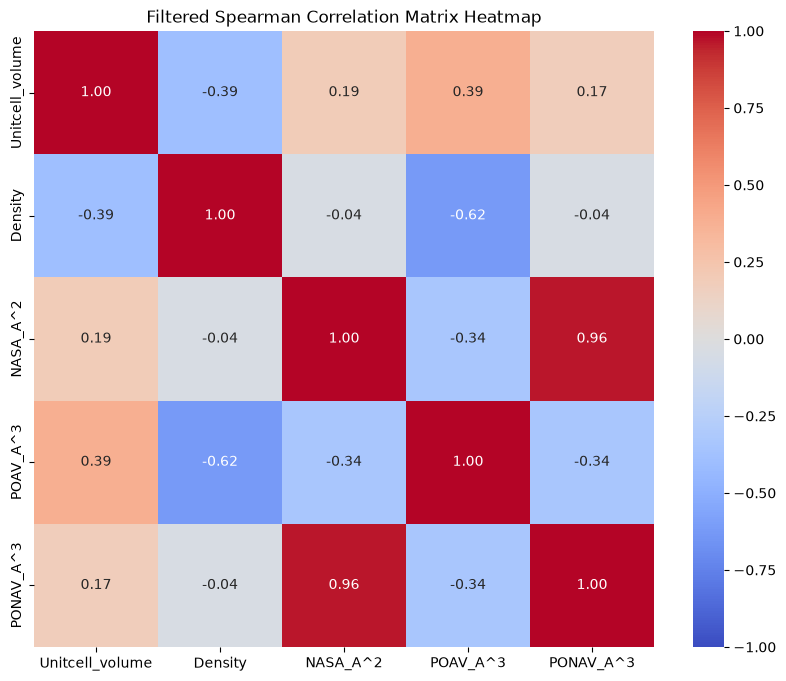

In [4]:
# manually drop other 2 pore size descriptors
df_features.drop(columns=["Largest included sphere along free sphere path","Largest included sphere"], inplace=True)
df_clean.drop(columns=["Largest included sphere along free sphere path","Largest included sphere"], inplace=True)

print("\nDropped 2 features related to pore geometry")

# manually drop features repeated in different units 
target_units = ["/g", "/cm^3", "Volume_fraction"]
repeat_unit_cols = [col for col in df_features.columns if any(sub in col for sub in target_units)]
df_features.drop(columns=repeat_unit_cols, inplace=True)
df_clean.drop(columns=repeat_unit_cols, inplace=True)

print(f"\nDropped {len(repeat_unit_cols)} repeat features (different units only)")

print(f"\nColumns remaining: {len(df_features.columns)}")

# filtering threshold for removing remaining redundant features
corr_threshold = 0.99

# recalculate after dropping
corr_matrix = df_features.corr(method="spearman").abs()

# Get upper triangle mask of unique pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Build a list of all correlated pairs
pairs = (upper_tri.stack()[lambda x: x >= corr_threshold].index.tolist())

# Drop the feature with the most active correlated connections
cols_to_drop = set()
while pairs:
    # Count frequency of each remaining column in the high-correlation pairs
    col_counts = pd.Series([col for pair in pairs for col in pair]).value_counts()

    # Get the column involved in the most high-correlation pairs
    most_frequent_col = col_counts.idxmax()
    cols_to_drop.add(most_frequent_col)

    # Remove all pairs that include this dropped column
    pairs = [pair for pair in pairs if most_frequent_col not in pair]

# Print number of columns filtered for correlation
print(f"\nDropped {len(cols_to_drop)} correlated features")

# Drop selected features from both DataFrames
df_features_reduced = df_features.drop(columns=list(cols_to_drop))
df_clean_reduced = df_clean.drop(columns=list(cols_to_drop))

print("\nReduced Features DataFrame Shape: ", df_features_reduced.shape)

# New heatmap of reduced features
corr_matrix_reduced = df_features_reduced.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_reduced, cmap="coolwarm", vmin=-1, vmax=1,annot=True,fmt=".2f")
plt.title("Filtered Spearman Correlation Matrix Heatmap")
plt.savefig('figures/reduced_corr_heatmap.png')
#plt.show()

### *plot the distribution of the target property*


Beginning EDA...



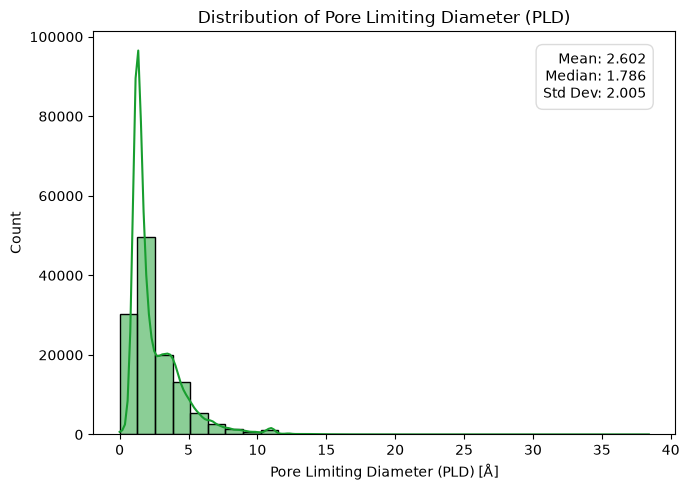

In [5]:
# EDA on reduced dataset
print("\nBeginning EDA...\n")

# Define target (PLD) for distribution plotting
target_col = "Largest free sphere" # AKA pore limiting diameter or PLD

# Initialize the plot
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the histogram with a KDE curve
sns.histplot(data=df_geom, x=target_col, kde=True, color="#189E2F", bins=30, ax=ax)

# Calculate key summary statistics for the distribution
mean_val = df_geom[target_col].mean()
median_val = df_geom[target_col].median()
std_val = df_geom[target_col].std()

# Format the statistical summary text block
stats_text = f"Mean: {mean_val:.3f}\nMedian: {median_val:.3f}\nStd Dev: {std_val:.3f}"

# Place stats text box
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'))

# Label and title the plot
ax.set_xlabel('Pore Limiting Diameter (PLD) [Å]')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pore Limiting Diameter (PLD)')

# Save figure
plt.tight_layout()
plt.savefig('figures/PLD_distribution.png')

### *plot correlations of target property with remaining features*

...EDA complete. See saved figures.


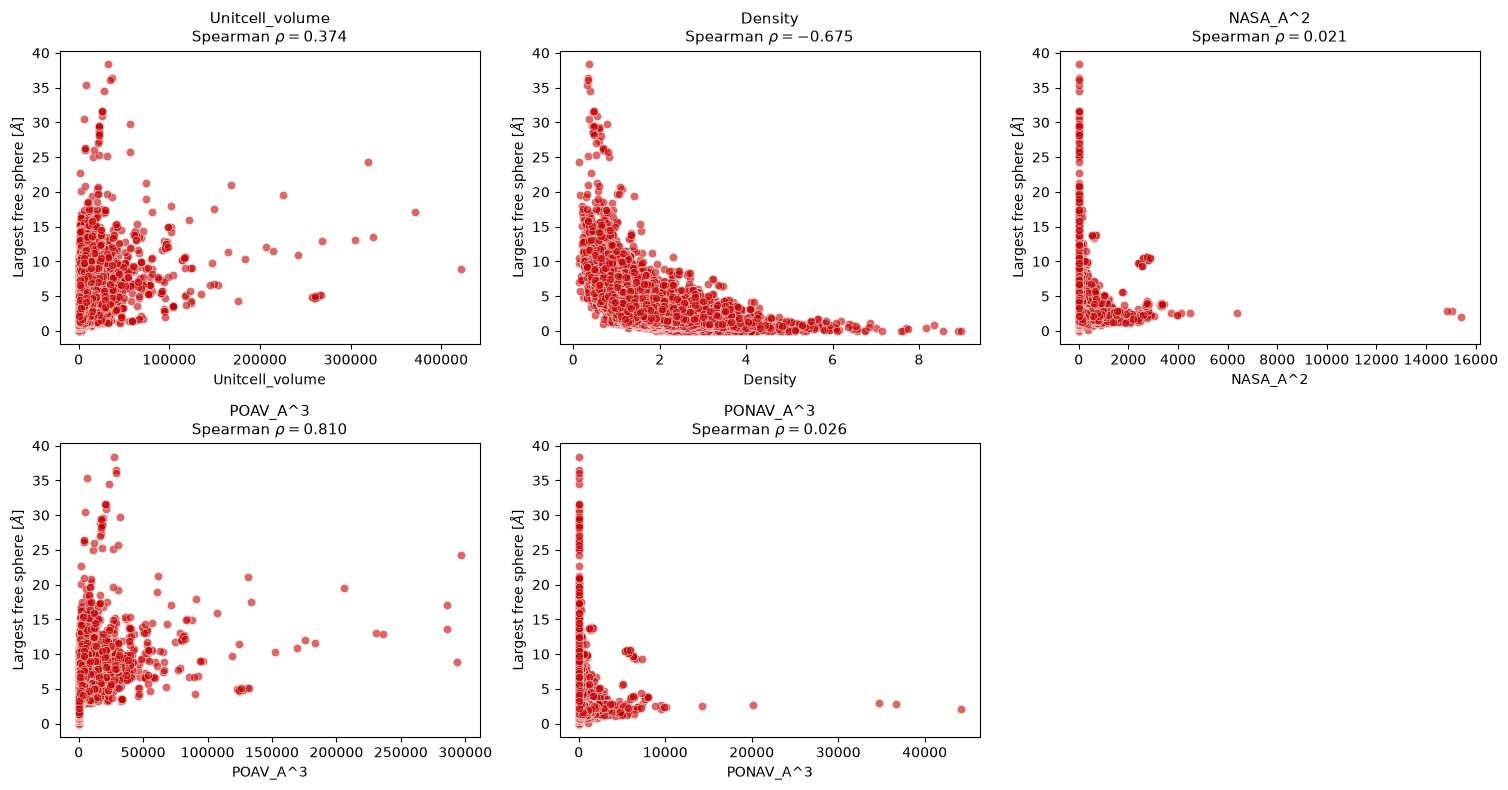

In [6]:
# Exclude grouping column of strings from target-feature plotting
exclude_cols = ["cif", target_col]

# features to plot vs target
feature_cols = [col for col in df_clean_reduced.columns if col not in exclude_cols]

# Size subplot grid shape
n_features = len(feature_cols)
n_cols = 3  # columns of plots
n_rows = int(np.ceil(n_features / n_cols))

# Set up figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

# Plot each feature against PLD
for i, col in enumerate(feature_cols):
    
    ax = axes[i]

    # Compute Spearman rank correlation coefficient
    rho = df_clean_reduced[col].corr(df_clean_reduced[target_col], method="spearman")

    # Scatter plot points
    sns.scatterplot(
        data=df_clean_reduced,
        x=col,
        y=target_col,
        ax=ax,
        alpha=0.6,
        color="#C70202",
    )

    # Labeling
    ax.set_title(f"{col}\nSpearman $\\rho = {rho:.3f}$", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col+ " [$\AA$]")

# Hide unused empty axes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Save figure
plt.tight_layout()
plt.savefig('figures/target_feature_correlations.png')

print("...EDA complete. See saved figures.")

### *save the processed dataset*

In [7]:
# Fresh copy of the clean data frame to prepare for modeling step
df_model_ready = df_clean_reduced.copy()

# Prepare grouping column by truncating ID column to only the first 6 characters: the CSD refcode for each entry
df_model_ready["cif"] = df_model_ready["cif"].astype(str).str[:6]

# saving the data frame for modelling
df_model_ready.to_csv("data/model_ready_data.csv", index=False)
print("\nSaved df_model_ready to 'data/model_ready_data.csv' -> Proceed to 03_modeling....\n")


Saved df_model_ready to 'data/model_ready_data.csv' -> Proceed to 03_modeling....

